In [1]:
import pandas as pd

cytosol_prot = pd.read_csv("//wsl.localhost/Ubuntu/home/cezar/algo/project/subcell_location_Aggresome_Cytosol_Cytoplasmic.tsv", sep="\t")
mitochondria_prot = pd.read_csv("//wsl.localhost/Ubuntu/home/cezar/algo/project/subcell_location_Mitochondria.tsv", sep="\t")



In [2]:
import requests

url = "https://rest.uniprot.org/uniprotkb/stream?compressed=false&format=fasta&query=%28organism_id%3A9606%29%20AND%20%28reviewed%3Atrue%29"

response = requests.get(url)

with open("human_sprot.fasta", "w") as f:
    f.write(response.text)

print("Downloaded human_sprot.fasta")



Downloaded human_sprot.fasta


In [3]:
# Build a UniProt Dictionary
from Bio import SeqIO

seq_dict = {}

for record in SeqIO.parse("human_sprot.fasta", "fasta"):
    accession = record.id.split("|")[1]
    seq_dict[accession] = str(record.seq)[:50]

print(f"Loaded {len(seq_dict)} protein sequences")

Loaded 20431 protein sequences


In [4]:
mitochondria_prot["Uniprot_clean"] = (
    mitochondria_prot["Uniprot"]
    .astype(str)
    .str.split("-")
    .str[0]
)

cytosol_prot["Uniprot_clean"] = (
    cytosol_prot["Uniprot"]
    .astype(str)
    .str.split("-")
    .str[0]
)

mitochondria_prot["AA_sequence_50"] = (
    mitochondria_prot["Uniprot_clean"]
    .map(seq_dict)
)

cytosol_prot["AA_sequence_50"] = (
    cytosol_prot["Uniprot_clean"]
    .map(seq_dict)
)

In [5]:
print(
    mitochondria_prot[
        ["Gene", "Uniprot", "AA_sequence_50"]
    ].head()
)

print(
    f"Mitochondrial matches: "
    f"{mitochondria_prot['AA_sequence_50'].notna().sum()} / {len(mitochondria_prot)}"
)

print(
    f"Cytosolic matches: "
    f"{cytosol_prot['AA_sequence_50'].notna().sum()} / {len(cytosol_prot)}"
)

     Gene Uniprot                                     AA_sequence_50
0  A4GALT  Q9NPC4  MSKPPDLLLRLLRGAPRQRVCTLFIIGFKFTFFVSIMIYWHVVGEP...
1   AARS2  Q5JTZ9  MAASVAAAARRLRRAIRRSPAWRGLSHRPLSSEPPAAKASAVRAAF...
2    AASS  Q9UDR5  MLQVHRTGLGRLGVSLSKGLHHKAVLAVRREDVNAWERRAPLAPKH...
3    AATK  Q6ZMQ8  MSSSFFNPSFAFSSHFDPDGAPLSELSWPSSLAVVAVSFSGLFAVI...
4    ABAT  P80404  MASMLLAQRLACSFQHSYRLLVPGSRHISQAAAKVDVEFDYDGPLM...
Mitochondrial matches: 1112 / 1132
Cytosolic matches: 5241 / 5341


In [6]:
full_seq_dict = {}

for record in SeqIO.parse("human_sprot.fasta", "fasta"):
    accession = record.id.split("|")[1]
    full_seq_dict[accession] = str(record.seq)

mitochondria_prot["AA_sequence"] = mitochondria_prot["Uniprot_clean"].map(full_seq_dict)
mitochondria_prot["AA_sequence_50"] = mitochondria_prot["AA_sequence"].str[:50]

cytosol_prot["AA_sequence"] = cytosol_prot["Uniprot_clean"].map(full_seq_dict)
cytosol_prot["AA_sequence_50"] = cytosol_prot["AA_sequence"].str[:50]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Amino acid setup 
# -----------------------------
AA = ['A','R','N','D','C','Q','E','G','H','I',
      'L','K','M','F','P','S','T','W','Y','V']

aa_to_idx = {a: i for i, a in enumerate(AA)}
n_aa = len(AA)

# -----------------------------
# 2. Load background frequencies
# -----------------------------
background = pd.read_csv(
    "//wsl.localhost/Ubuntu/home/cezar/algo/data/Matrices/bg.freq.fmt",
    header=None
)

bg = background.iloc[:, 0].to_numpy(dtype=float)
bg = bg / bg.sum()

print("Background frequencies loaded:")
print(f"Length: {len(bg)}, Sum: {bg.sum()}")
print(bg)

# -----------------------------
# 3. Encode sequences
# -----------------------------
def encode(seq):
    seq = str(seq).upper()
    return np.array([aa_to_idx[a] for a in seq if a in aa_to_idx], dtype=int)

seqs = (
    mitochondria_prot["AA_sequence_50"]
    .dropna()
    .astype(str)
    .apply(encode)
    .tolist()
)

seqs = [s for s in seqs if len(s) > 0]
print(seqs)

Background frequencies loaded:
Length: 20, Sum: 1.0
[0.074 0.052 0.045 0.054 0.025 0.034 0.054 0.074 0.026 0.068 0.099 0.058
 0.025 0.047 0.039 0.057 0.051 0.013 0.032 0.073]
[array([12, 15, 11, 14, 14,  3, 10, 10, 10,  1, 10, 10,  1,  7,  0, 14,  1,
        5,  1, 19,  4, 16, 10, 13,  9,  9,  7, 13, 11, 13, 16, 13, 13, 19,
       15,  9, 12,  9, 18, 17,  8, 19, 19,  7,  6, 14, 11,  6, 11,  7]), array([12,  0,  0, 15, 19,  0,  0,  0,  0,  1,  1, 10,  1,  1,  0,  9,  1,
        1, 15, 14,  0, 17,  1,  7, 10, 15,  8,  1, 14, 10, 15, 15,  6, 14,
       14,  0,  0, 11,  0, 15,  0, 19,  1,  0,  0, 13, 10,  2, 13, 13]), array([12, 10,  5, 19,  8,  1, 16,  7, 10,  7,  1, 10,  7, 19, 15, 10, 15,
       11,  7, 10,  8,  8, 11,  0, 19, 10,  0, 19,  1,  1,  6,  3, 19,  2,
        0, 17,  6,  1,  1,  0, 14, 10,  0, 14, 11,  8,  9, 11,  7,  9]), array([12, 15, 15, 15, 13, 13,  2, 14, 15, 13,  0, 13, 15, 15,  8, 13,  3,
       14,  3,  7,  0, 14, 10, 15,  6, 10, 15, 17, 14, 15, 15, 10,  0, 19,
     

In [8]:

# -----------------------------
# 4. HMM initialization
# -----------------------------
def make_positive_hmm(bg):
    K = 4  # States: 0=back, 1=N-region, 2=H-region, 3=C-region
    
    # Left-to-right transitions
    A = np.array([
        [0.90, 0.10, 0.00, 0.00],
        [0.00, 0.70, 0.30, 0.00],
        [0.00, 0.00, 0.75, 0.25],
        [0.00, 0.00, 0.00, 1.00],
    ], dtype=float)
    
    pi = np.array([1.0, 0.0, 0.0, 0.0], dtype=float)
    
    E = np.vstack([bg.copy(), bg.copy(), bg.copy(), bg.copy()])
    
    # N-region: enrich K,R
    E[1, aa_to_idx['K']] += 2.0
    E[1, aa_to_idx['R']] += 2.0
    
    # H-region: enrich hydrophobics
    for aa in ['A','I','L','M','F','V','W','Y','C']:
        E[2, aa_to_idx[aa]] += 2.0
    
    # C-region: enrich small residues
    for aa in ['A','S','T','G','P']:
        E[3, aa_to_idx[aa]] += 1.0
    
    # Normalize emissions
    E = E / E.sum(axis=1, keepdims=True)
    
    return A, E, pi


In [9]:

# -----------------------------
# 5. Forward/Backward in log space - not sure about forward.
# -----------------------------
def logsumexp(x, axis=None):
    x = np.asarray(x)
    m = np.max(x, axis=axis, keepdims=True)
    out = m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True) + 1e-300)
    if axis is not None:
        out = np.squeeze(out, axis=axis)
    return out

def forward_backward_log(seq, A, E, pi):
    K = A.shape[0]
    T = len(seq)
    logA = np.log(A + 1e-300)
    logE = np.log(E + 1e-300)
    logpi = np.log(pi + 1e-300)
    
    log_alpha = np.full((T, K), -np.inf)
    log_beta = np.full((T, K), -np.inf)
    
    # Forward
    log_alpha[0] = logpi + logE[:, seq[0]]
    for t in range(1, T):
        for j in range(K):
            log_alpha[t, j] = logE[j, seq[t]] + logsumexp(log_alpha[t-1] + logA[:, j])
    
    # Backward
    log_beta[-1] = 0.0
    for t in range(T-2, -1, -1):
        for i in range(K):
            log_beta[t, i] = logsumexp(logA[i, :] + logE[:, seq[t+1]] + log_beta[t+1, :])
    
    log_ll = logsumexp(log_alpha[-1], axis=0)
    return log_alpha, log_beta, log_ll

In [10]:

# -----------------------------
# 6. Baum-Welch training
# -----------------------------
def train_hmm(seqs, bg, n_iter=50, pseudocount=1e-3, verbose=True):
    A, E, pi = make_positive_hmm(bg)
    K = A.shape[0]
    ll_trace = []
    
    for it in range(n_iter):
        A_num = np.zeros((K, K))
        A_den = np.zeros(K)
        E_num = np.zeros((K, n_aa))
        pi_new = np.zeros(K)
        total_ll = 0.0
        
        for seq in seqs:
            if len(seq) < 2:
                continue
            
            log_alpha, log_beta, log_ll = forward_backward_log(seq, A, E, pi)
            total_ll += float(log_ll)
            
            log_gamma = log_alpha + log_beta - log_ll
            gamma = np.exp(log_gamma)
            
            pi_new += gamma[0]
            
            # Emission counts
            for t, a in enumerate(seq):
                E_num[:, a] += gamma[t]
            
            # Transition counts
            logA = np.log(A + 1e-300)
            logE = np.log(E + 1e-300)
            
            for t in range(len(seq) - 1):
                log_xi = (
                    log_alpha[t][:, None]
                    + logA
                    + logE[:, seq[t+1]][None, :]
                    + log_beta[t+1][None, :]
                    - log_ll
                )
                xi = np.exp(log_xi)
                A_num += xi
                A_den += xi.sum(axis=1)
        
        # M-step
        A = A_num + pseudocount
        A = A / A.sum(axis=1, keepdims=True)
        
        E = E_num + pseudocount
        E = E / E.sum(axis=1, keepdims=True)
        
        pi = pi_new + pseudocount
        pi = pi / pi.sum()
        
        ll_trace.append(total_ll)
        if verbose:
            print(f"Iteration {it+1:02d}: log-likelihood = {total_ll:.3f}")
    
    return A, E, pi, ll_trace


=== Training HMM ===


C:\Users\moise\AppData\Local\Temp\ipykernel_30652\2381383371.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_alpha[t, j] = logE[j, seq[t]] + logsumexp(log_alpha[t-1] + logA[:, j])
C:\Users\moise\AppData\Local\Temp\ipykernel_30652\2381383371.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_beta[t, i] = logsumexp(logA[i, :] + logE[:, seq[t+1]] + log_beta[t+1, :])


Iteration 01: log-likelihood = -132678.023
Iteration 02: log-likelihood = -126216.660
Iteration 03: log-likelihood = -125916.301
Iteration 04: log-likelihood = -125753.683
Iteration 05: log-likelihood = -125641.788
Iteration 06: log-likelihood = -125534.073
Iteration 07: log-likelihood = -125412.387
Iteration 08: log-likelihood = -125299.522
Iteration 09: log-likelihood = -125213.766
Iteration 10: log-likelihood = -125155.254

=== Scoring mitochondrial test proteins ===

=== Scoring cytosolic proteins ===

ROC AUC = 0.603


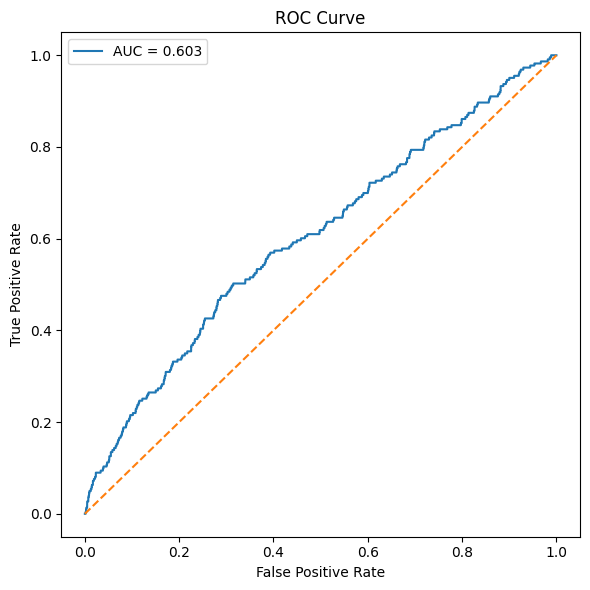

C:\Users\moise\AppData\Local\Temp\ipykernel_30652\2381383371.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_alpha[t, j] = logE[j, seq[t]] + logsumexp(log_alpha[t-1] + logA[:, j])
C:\Users\moise\AppData\Local\Temp\ipykernel_30652\2381383371.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_beta[t, i] = logsumexp(logA[i, :] + logE[:, seq[t+1]] + log_beta[t+1, :])



Top 10 mitochondrial proteins:
         Gene Uniprot    HMM_LLR  HMM_Prob
978     TACO1  Q9BSH4  24.471923       1.0
720    NT5DC3  Q86UY8  23.040554       1.0
179   CHCHD10  Q8WYQ3  23.024812       1.0
510    LRPPRC  P42704  22.970172       1.0
287      DNLZ  Q5SXM8  22.964532       1.0
1054    TTC9B  Q8N6N2  22.857600       1.0
638   MTHFD1L  Q6UB35  22.804457       1.0
661      NAGS  Q8N159  22.538800       1.0
410    GTPBP6  O43824  22.303145       1.0
248    D2HGDH  Q8N465  22.237946       1.0


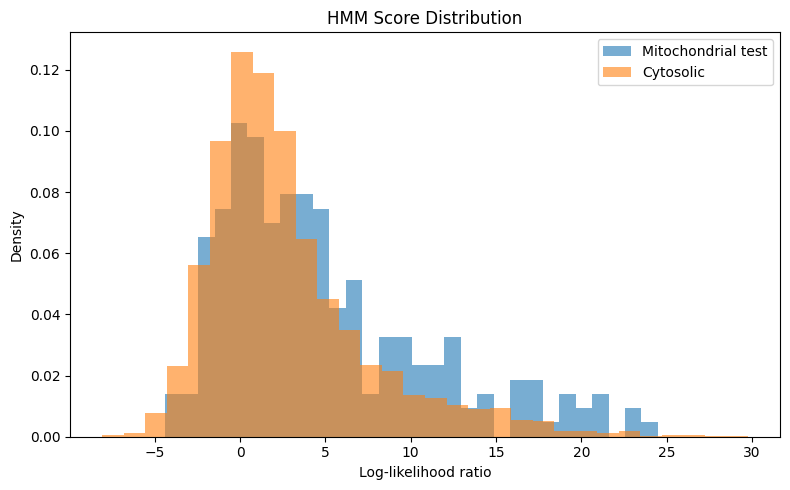

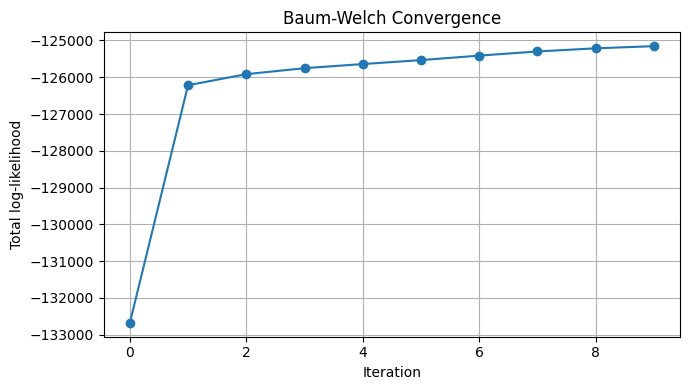


Results saved to mitochondrial_HMM_scores.csv


In [11]:
# -----------------------------
# 7. Encode cytosolic sequences
# -----------------------------
seqs_cytosol = (
    cytosol_prot["AA_sequence_50"]
    .dropna()
    .astype(str)
    .apply(encode)
    .tolist()
)

seqs_cytosol = [s for s in seqs_cytosol if len(s) > 0]


# -----------------------------
# 8. Train / test split on mitochondrial proteins
# -----------------------------
from sklearn.model_selection import train_test_split

seqs_train, seqs_test, idx_train, idx_test = train_test_split(
    seqs,
    np.arange(len(seqs)),
    test_size=0.20,
    random_state=42,
    shuffle=True
)


# -----------------------------
# 9. Train HMM on mitochondrial training proteins only
# -----------------------------
print("\n=== Training HMM ===")

A_pos, E_pos, pi_pos, ll_trace = train_hmm(
    seqs=seqs_train,
    bg=bg,
    n_iter=10,
    pseudocount=1e-3,
    verbose=True
)


# -----------------------------
# 10. Scoring function
# -----------------------------
def score_sequence_llr(seq, A_pos, E_pos, pi_pos, bg):

    if len(seq) == 0:
        return np.nan

    _, _, ll_pos = forward_backward_log(
        seq,
        A_pos,
        E_pos,
        pi_pos
    )

    ll_bg = np.sum(
        np.log(bg[seq] + 1e-300)
    )

    return float(ll_pos - ll_bg)


# -----------------------------
# 11. Score mitochondrial TEST proteins
# -----------------------------
print("\n=== Scoring mitochondrial test proteins ===")

llr_mito_test = np.array([
    score_sequence_llr(
        s,
        A_pos,
        E_pos,
        pi_pos,
        bg
    )
    for s in seqs_test
])


# -----------------------------
# 12. Score cytosolic proteins
# -----------------------------
print("\n=== Scoring cytosolic proteins ===")

llr_cytosol = np.array([
    score_sequence_llr(
        s,
        A_pos,
        E_pos,
        pi_pos,
        bg
    )
    for s in seqs_cytosol
])


# -----------------------------
# 13. ROC AUC
# -----------------------------
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

y_true = np.concatenate([
    np.ones(len(llr_mito_test)),
    np.zeros(len(llr_cytosol))
])

scores = np.concatenate([
    llr_mito_test,
    llr_cytosol
])

auc = roc_auc_score(
    y_true,
    scores
)

print(f"\nROC AUC = {auc:.3f}")


# -----------------------------
# 14. ROC curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(
    y_true,
    scores
)

plt.figure(figsize=(6,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 15. Score ALL mitochondrial proteins
# -----------------------------
llr_all = np.array([
    score_sequence_llr(
        s,
        A_pos,
        E_pos,
        pi_pos,
        bg
    )
    for s in seqs
])

prob_all = 1.0 / (
    1.0 + np.exp(-llr_all)
)


# -----------------------------
# 16. Build result table
# -----------------------------
result = mitochondria_prot.loc[
    mitochondria_prot["AA_sequence_50"].notna(),
    ["Gene", "Uniprot", "AA_sequence_50"]
].copy()

result["HMM_LLR"] = llr_all
result["HMM_Prob"] = prob_all

result = result.sort_values(
    "HMM_LLR",
    ascending=False
)

print("\nTop 10 mitochondrial proteins:")

print(
    result[
        ["Gene", "Uniprot", "HMM_LLR", "HMM_Prob"]
    ].head(10)
)


# -----------------------------
# 17. Distribution plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.hist(
    llr_mito_test,
    bins=30,
    alpha=0.6,
    density=True,
    label="Mitochondrial test"
)

plt.hist(
    llr_cytosol,
    bins=30,
    alpha=0.6,
    density=True,
    label="Cytosolic"
)

plt.xlabel("Log-likelihood ratio")
plt.ylabel("Density")
plt.title("HMM Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# 18. Baum-Welch convergence
# -----------------------------
plt.figure(figsize=(7,4))
plt.plot(ll_trace, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Total log-likelihood")
plt.title("Baum-Welch Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------
# 19. Save results
# -----------------------------
result.to_csv(
    "mitochondrial_HMM_scores.csv",
    index=False
)

print(
    "\nResults saved to mitochondrial_HMM_scores.csv"
)